Shape: (4419, 246)
Columns (first 30): ['CU_NUMBER', 'CYCLE_DATE', 'JOIN_NUMBER', 'UPDATE_DATE', 'ACCT_007', 'ACCT_008', 'ACCT_009', 'ACCT_010', 'ACCT_011C', 'ACCT_013', 'ACCT_018', 'ACCT_019', 'ACCT_021B', 'ACCT_022B', 'ACCT_023B', 'ACCT_025A', 'ACCT_025B', 'ACCT_031A', 'ACCT_031B', 'ACCT_041B', 'ACCT_042', 'ACCT_058C', 'ACCT_065', 'ACCT_067', 'ACCT_068', 'ACCT_069', 'ACCT_080', 'ACCT_083', 'ACCT_084', 'ACCT_100']

Missing Values (top 10):
 CU_NUMBER      0
CYCLE_DATE     0
JOIN_NUMBER    0
UPDATE_DATE    0
ACCT_007       0
ACCT_008       0
ACCT_009       0
ACCT_010       0
ACCT_011C      0
ACCT_013       0
dtype: int64

First 5 rows (first 10 columns):
  CU_NUMBER        CYCLE_DATE  JOIN_NUMBER            UPDATE_DATE  ACCT_007  ACCT_008  ACCT_009   ACCT_010  ACCT_011C  ACCT_013
         1 9/30/2025 0:00:00            2 10/28/2025 10:43:30 PM     40498      8200         0   12676797          0  11225414
         6 9/30/2025 0:00:00            7 10/30/2025 10:26:41 PM   2660277   10825

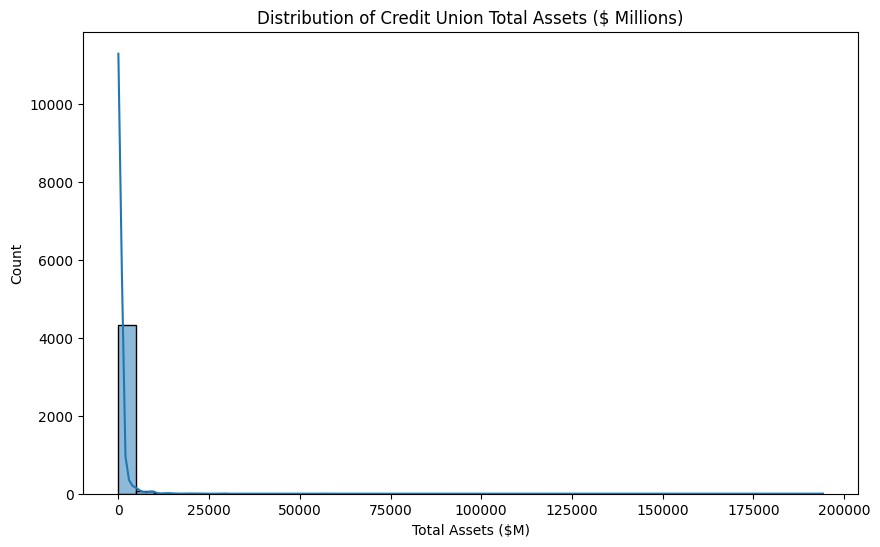

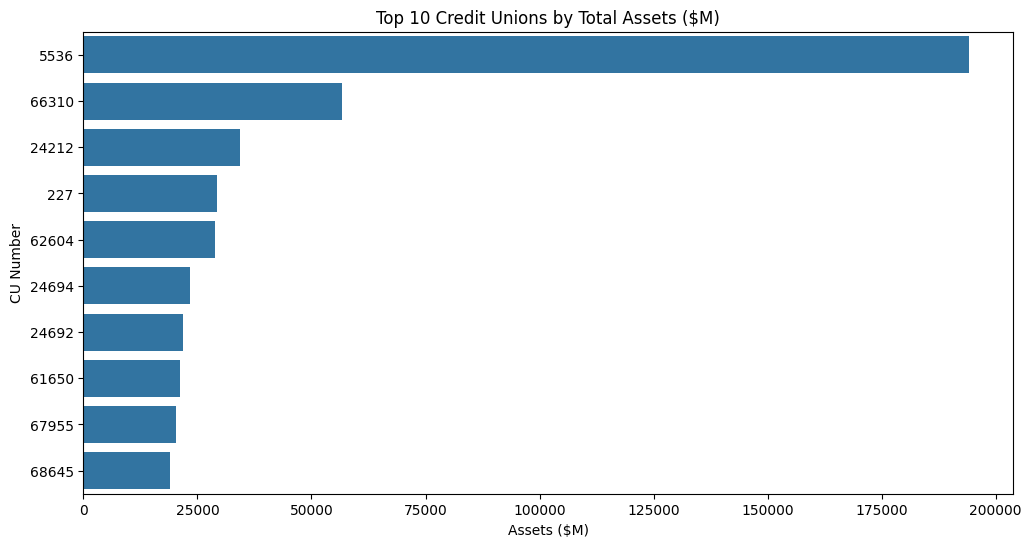

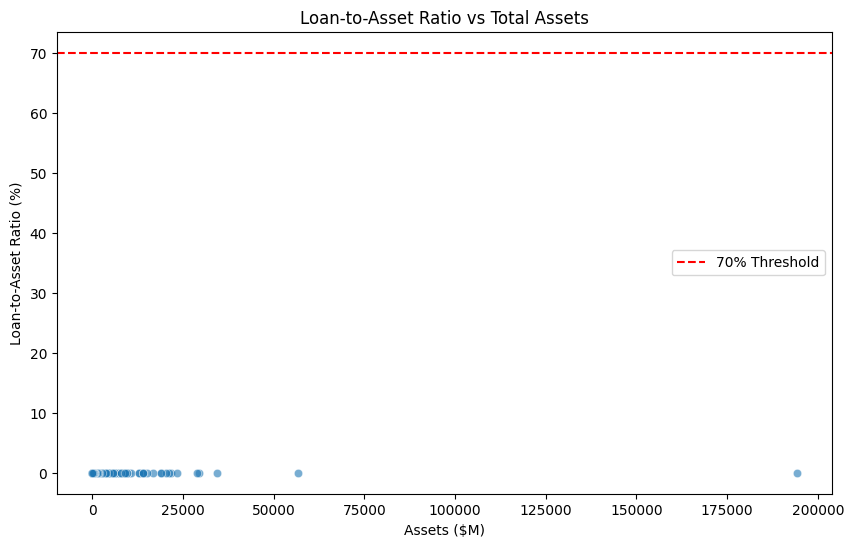


Excel report saved: reports/credit_union_analysis_report.xlsx
→ Go to Files pane → right-click → Download from 'reports' folder


In [ ]:
# =============================================================================
# Credit Union Financial Health Analyzer
# =============================================================================



!pip install pandasql seaborn openpyxl -q

# ────────────────────────────────────────────────
# 2. Imports
# ────────────────────────────────────────────────
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pandasql import sqldf
import os

# Create output folders
os.makedirs('viz', exist_ok=True)
os.makedirs('reports', exist_ok=True)

# ────────────────────────────────────────────────
# 3. Load the data
# ────────────────────────────────────────────────
# Upload FS220.txt
file_path = '/content/FS220.txt'  # ← change if your filename is different

df = pd.read_csv(
    file_path,
    sep=',',
    quotechar='"',
    encoding='cp1252',
    low_memory=False,
    on_bad_lines='skip'
)

print("Shape:", df.shape)
print("Columns (first 30):", df.columns.tolist()[:30])
print("\nMissing Values (top 10):\n", df.isna().sum().sort_values(ascending=False).head(10))
print("\nFirst 5 rows (first 10 columns):\n", df.head().iloc[:, :10].to_string(index=False))

# ────────────────────────────────────────────────
# 4. Define key columns
# ────────────────────────────────────────────────
ASSETS     = 'ACCT_010'   # Total Assets
NET_WORTH  = 'ACCT_931'   # Net Worth (note: many zeros in sample - may be in another file)
LOANS      = 'ACCT_400'   # Total Loans (note: many zeros - may be aggregated in sub-files)

# ────────────────────────────────────────────────
# 5. Data Validation & Cleaning
# ────────────────────────────────────────────────
df['is_valid'] = (df[ASSETS] > 0) & (df[NET_WORTH] >= 0)
invalid_count = len(df) - df['is_valid'].sum()
print(f"Invalid rows removed: {invalid_count} ({invalid_count/len(df):.1%})")
df = df[df['is_valid']].copy()

# Derived business metrics
df['loan_to_asset_pct']   = (df[LOANS] / df[ASSETS]) * 100
df['net_worth_ratio_pct'] = (df[NET_WORTH] / df[ASSETS]) * 100

# ────────────────────────────────────────────────
# 6. SQL Queries
# ────────────────────────────────────────────────
pysqldf = lambda q: sqldf(q, globals())

# Query 1: Top 10 Credit Unions by Total Assets
top_assets = pysqldf(f"""
SELECT CU_NUMBER, {ASSETS} AS Total_Assets
FROM df
WHERE {ASSETS} > 0
ORDER BY Total_Assets DESC
LIMIT 10
""")
print("\nSQL Query 1 - Top 10 by Assets:\n", top_assets)

# Query 2: High Loan-to-Asset Ratio (>70%)
high_growth = pysqldf(f"""
SELECT * FROM (
    SELECT
        CU_NUMBER,
        {LOANS} AS Loans,
        {ASSETS} AS Assets,
        ROUND(({LOANS} * 100.0 / {ASSETS}), 2) AS Loan_to_Asset_Pct
    FROM df
    WHERE {ASSETS} > 0 AND {LOANS} > 0
)
WHERE Loan_to_Asset_Pct > 70
ORDER BY Loan_to_Asset_Pct DESC
LIMIT 10
""")
print("\nSQL Query 2 - High Loan-to-Asset Ratio (>70%):\n", high_growth)

# ────────────────────────────────────────────────
# 7. Basic Statistics
# ────────────────────────────────────────────────
key_cols = [ASSETS, NET_WORTH, LOANS, 'loan_to_asset_pct', 'net_worth_ratio_pct']
stats = df[key_cols].describe()
print("\nKey Financial Statistics:\n", stats)

# ────────────────────────────────────────────────
# 8. Visualizations
# ────────────────────────────────────────────────

# Plot 1: Assets Distribution
plt.figure(figsize=(10,6))
sns.histplot(df[ASSETS] / 1_000_000, bins=40, kde=True)
plt.title('Distribution of Credit Union Total Assets ($ Millions)')
plt.xlabel('Total Assets ($M)')
plt.ylabel('Count')
plt.savefig('viz/assets_distribution.png')
plt.show()

# Plot 2: Top 10 Assets Bar
plt.figure(figsize=(12,6))
sns.barplot(x=top_assets['Total_Assets'] / 1_000_000, y=top_assets['CU_NUMBER'].astype(str))
plt.title('Top 10 Credit Unions by Total Assets ($M)')
plt.xlabel('Assets ($M)')
plt.ylabel('CU Number')
plt.savefig('viz/top_10_assets_bar.png')
plt.show()

# Plot 3: Loan-to-Asset Scatter
plt.figure(figsize=(10,6))
sns.scatterplot(x=df[ASSETS]/1e6, y=df['loan_to_asset_pct'], alpha=0.6)
plt.axhline(70, color='red', linestyle='--', label='70% Threshold')
plt.title('Loan-to-Asset Ratio vs Total Assets')
plt.xlabel('Assets ($M)')
plt.ylabel('Loan-to-Asset Ratio (%)')
plt.legend()
plt.savefig('viz/loan_to_asset_scatter.png')
plt.show()

# ────────────────────────────────────────────────
# 9. EXCEL
# ────────────────────────────────────────────────
excel_path = 'reports/credit_union_analysis_report.xlsx'
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='Raw_Data', index=False)
    stats.to_excel(writer, sheet_name='Statistics')
    top_assets.to_excel(writer, sheet_name='Top_Assets_SQL')
    high_growth.to_excel(writer, sheet_name='High_Growth_SQL')

print(f"\nExcel report saved: {excel_path}")
print("→ Go to Files pane → right-click → Download from 'reports' folder")